# Combined Analysis: Two-Point Correlators $\xi_{ab}(r, t)$

Computes all three two-point correlators ($\xi_{11}$, $\xi_{22}$) up to
perturbative order 4, using `compute_moment` (symbolic pipeline).
Simulation data loaded from `sim_cache.npz`.

In [1]:
import sys, os, pickle, numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import defaultdict

sys.path.insert(0, "/Users/zzhang/projects/SFT/sft-wick/src")
from sft_wick.evaluate import (
    PropagatorModel, PropagatorCache, integrate_two_point_qmc,
    DiagramIntegrand,
)
from scipy.interpolate import RectBivariateSpline



# ---------- Physical parameters ----------
lam      = 0.05
sigma_t  = 0.3
sigma_x  = 1.0
gamma    = 1.0
N_comp   = 2
T_MAX    = 100.0
# ---------- Global font sizes ----------
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'figure.titlesize': 15,
})



In [2]:

# ---------- Analytical propagator cache (no grid, no file) ----------
class AnalyticalCache:
    """Direct evaluation of R and C for exponential kernel — no splines."""

    def __init__(self, gamma, lam, sigma_t, n_components):
        self.gamma = gamma
        self.lam = lam
        self.alpha = 1.0 / sigma_t
        self.N = n_components
        _self = self
        def _kappa2(n1, t1, n2, t2):
            kt = _self.lam * np.exp(-np.abs(t1 - t2) * _self.alpha)
            kx = np.exp(-np.abs(np.asarray(n1) - np.asarray(n2)) / sigma_x)
            return kt * kx * np.eye(n_components)
        def _R(t1, t2):
            return np.exp(-_self.gamma * (t1 - t2)) if t1 >= t2 else 0.0
        self.model = type("M", (), {
            "n_components": n_components,
            "iso_R": True,
            "diag_C": True,
            "t_min": 0.0,
            "kappa2": staticmethod(_kappa2),
            "R_time": staticmethod(_R),
        })()
        # Needed by C_diagonal_batch — pretend we have splines
        self._c_splines = True  # non-None sentinel

    def _C_scalar(self, t1, t2):
        """Scalar C(t1, t2) for one component."""
        g, a, lam = self.gamma, self.alpha, self.lam
        t_lo = min(t1, t2)
        t_hi = max(t1, t2)
        if t_lo <= 0:
            return 0.0
        gpa, gma = g + a, g - a
        E1 = np.expm1(2*g*t_lo) / (2*g)
        E2 = t_lo if abs(gma) < 1e-14 else np.expm1(gma*t_lo) / gma
        E3 = np.expm1(gpa*t_lo) / gpa
        E4 = np.exp(gma * t_hi)
        I = E1/gpa - E2/gpa + E4*E3/gma - E1/gma
        return lam * np.exp(-g*(t1+t2)) * I

    def R_time(self, t1, t2):
        return np.exp(-self.gamma * (t1 - t2)) if t1 >= t2 else 0.0

    def R_product(self, r_pairs, times):
        result = 1.0
        for sl, sr in r_pairs:
            result *= float(self.R_time(times[sl], times[sr]))
        return result

    def R_time_batch(self, t1, t2):
        return np.where(t1 >= t2, np.exp(-self.gamma * (t1 - t2)), 0.0)

    def C_value(self, n1, t1, n2, t2):
        c = self._C_scalar(t1, t2)
        return c * np.eye(self.N)

    def C_diagonal(self, n, t1, n_prime=None, t2=None):
        if t2 is None:
            t2 = t1
        c = self._C_scalar(t1, t2)
        return np.full(self.N, c)

    def C_diagonal_batch(self, t1, t2):
        g, a, lam = self.gamma, self.alpha, self.lam
        t_lo = np.minimum(t1, t2)
        t_hi = np.maximum(t1, t2)
        gpa, gma = g + a, g - a
        E1 = np.expm1(2*g*t_lo) / (2*g)
        E2 = t_lo if abs(gma) < 1e-14 else np.expm1(gma*t_lo) / gma
        E3 = np.expm1(gpa*t_lo) / gpa
        E4 = np.exp(gma * t_hi)
        I = E1/gpa - E2/gpa + E4*E3/gma - E1/gma
        c = lam * np.exp(-g*(t1+t2)) * I
        return np.column_stack([c] * self.N)

cache = AnalyticalCache(gamma, lam, sigma_t, N_comp)
print(f"C(0,0) = {cache._C_scalar(0,0):.6f}")
print(f"C(10,10) = {cache._C_scalar(10,10):.6f}")
print(f"C(3,1) = {cache._C_scalar(3,1):.6f}")


C(0,0) = 0.000000
C(10,10) = 0.011538
C(3,1) = 0.001841


In [3]:
# ---------- Generate diagram terms (order 0-4) via compute_moment ----------
import time as _time
from sft_wick.fields import Field, reset_uid_counter
from sft_wick.vertices import Vertex
from sft_wick.action import Action
from sft_wick.perturbation import compute_moment

# Coupling tensor: F_{abc} psi_a phi_b phi_c (response FIRST)
F = np.zeros((N_comp, N_comp, N_comp))
F[0, 1, 1] = 1.0        # phi_1^2 drives phi_0
F[1, 0, 1] = 0.5        # phi_0 phi_1 drives phi_1 (symmetrised)
F[1, 1, 0] = 0.5
# F[1, 0, 0] = 1.0        # phi_1^2 drives phi_0
# F[0, 1, 0] = 0.5        # phi_0 phi_1 drives phi_1 (symmetrised)
# F[0, 0, 1] = 0.5
F_MSR = -1j * F

coupling_values = {'F': F_MSR}

reset_uid_counter()
phi = Field('phi', 'physical', n_components=N_comp)
psi = Field('psi', 'response', n_components=N_comp)
vertex = Vertex(fields=[psi, phi, phi], coupling='F', local=True)
action = Action(vertices=[vertex])
obs = [phi('a', 'x'), phi('b', 'y')]

t0 = _time.perf_counter()
result = compute_moment(
    obs, action, order=4,
    ito=True, response_phase=True, collect_topology=True,
    diag_R=True, diag_C=True, iso_R=True,
)
elapsed = _time.perf_counter() - t0
print(f'compute_moment(order=4): {elapsed:.2f}s')

diagram_terms = {n: result.diagram_terms(n) for n in range(5)}
for n in sorted(diagram_terms.keys()):
    dts = diagram_terms[n]
    if dts:
        print(f'  Order {n}: {len(dts)} diagram terms')

# Component pairs
PAIRS = [(0, 0), (1, 1)]
PAIR_LABELS = {(0,0): r'$\xi_{11}$', (1,1): r'$\xi_{22}$'}
ORDERS = [0, 2, 4]

# ---------- Build integrands per (order, a, b) ----------
integrands = {}
for order in ORDERS:
    dts = diagram_terms.get(order, [])
    for a, b in PAIRS:
        fi = {'a': a, 'b': b}
        igs = []
        for dt in dts:
            coeff = dt.evaluate_coupling(coupling_values, fixed_indices=fi)
            if np.abs(coeff).sum() > 1e-14:
                igs.append(dt.build_integrand(coupling_values, fixed_indices=fi))
        integrands[(order, a, b)] = igs
        if igs:
            print(f'  order {order}, ({a},{b}): {len(igs)} non-zero diagrams')
print(f'\nTotal integrand lists: {len(integrands)}')


compute_moment(order=4): 1.53s
  Order 0: 1 diagram terms
  Order 2: 6 diagram terms
  Order 4: 64 diagram terms
  order 0, (0,0): 1 non-zero diagrams
  order 0, (1,1): 1 non-zero diagrams
  order 2, (0,0): 4 non-zero diagrams
  order 2, (1,1): 5 non-zero diagrams
  order 4, (0,0): 43 non-zero diagrams


  order 4, (1,1): 54 non-zero diagrams

Total integrand lists: 6


In [4]:
# ---------- Integration backends + optimised xi_pert ----------
from collections import defaultdict
from numpy.polynomial.legendre import leggauss

# === Gauss-Legendre integrator (deterministic, high-accuracy) ===
def integrate_gl(integrands_list, t_f, positions, cache, n_gauss=20):
    """Gauss-Legendre quadrature on the causal time-ordered simplex.
    
    Uses the same [0,1]^d -> simplex mapping as the QMC code but with
    tensor-product GL nodes.  Deterministic, no seed dependence.
    For d<=4 and smooth integrands, converges to ~4 significant figures
    with n_gauss=20 (20^d evaluation points).
    """
    total = 0.0
    for ig in integrands_list:
        sp = ig.spatial
        dt_obj = ig.diagram_term
        coeff = ig.coupling_array
        ivars = list(reversed(sp.time_integration_vars))
        evars = list(sp.external_points)
        d = len(ivars)

        # Directions
        directions = {}
        for dvar in set(sp.direction_map.values()):
            for pt, mapped in sp.direction_map.items():
                if mapped == dvar:
                    directions[dvar] = positions.get(pt, 0.0)
                    break

        if d == 0:
            times = {v: t_f for v in evars}
            total += complex(ig.evaluate(times, directions, cache)).real
            continue

        # Parent map for causal ordering
        parent_map = defaultdict(list)
        for child, parent in sp.time_orderings:
            if child in ivars:
                parent_map[child].append(parent)

        # GL nodes on [0,1]
        gl_n, gl_w = leggauss(n_gauss)
        gl_n = (gl_n + 1) / 2
        gl_w = gl_w / 2

        # Tensor product on [0,1]^d
        grids = np.meshgrid(*[gl_n]*d, indexing='ij')
        u = np.stack([g.ravel() for g in grids], axis=1)  # (N, d)
        w = np.ones(u.shape[0])
        for g in np.meshgrid(*[gl_w]*d, indexing='ij'):
            w *= g.ravel()
        N = u.shape[0]

        # Map [0,1]^d -> causal simplex
        t_s = np.zeros((N, d))
        jac = np.ones(N)
        for k, var in enumerate(ivars):
            parents = parent_map.get(var, [])
            upper = np.full(N, t_f)
            for p in parents:
                if p in ivars:
                    upper = np.minimum(upper, t_s[:, ivars.index(p)])
                else:
                    upper = np.minimum(upper, t_f)
            ok = upper > 0
            t_s[:, k] = np.where(ok, u[:, k] * upper, 0.0)
            jac *= np.where(ok, upper, 0.0)

        # Full time array
        all_vars = evars + ivars
        v2c = {v: j for j, v in enumerate(all_vars)}
        tarr = np.empty((N, len(all_vars)))
        for j, v in enumerate(evars): tarr[:, j] = t_f
        for j, v in enumerate(ivars): tarr[:, len(evars)+j] = t_s[:, j]

        # R product
        r_prod = np.ones(N)
        for sl, sr in sp.r_propagators:
            r_prod *= cache.R_time_batch(tarr[:, v2c[sl]], tarr[:, v2c[sr]])

        # Spatial factors
        model = cache.model
        kappa_00 = model.kappa2(np.array([0.0]), 1.0, np.array([0.0]), 1.0)
        c_sf = []
        for sp_l, sp_r, _, _ in sp.c_propagators:
            dl, dr = sp.direction_map[sp_l], sp.direction_map[sp_r]
            nl, nr = directions.get(dl, 0.0), directions.get(dr, 0.0)
            if abs(nl - nr) < 1e-15:
                c_sf.append(np.ones(model.n_components))
            else:
                ks = model.kappa2(np.array([nl]), 1.0, np.array([nr]), 1.0)
                d00 = np.diag(kappa_00); ds = np.diag(ks)
                c_sf.append(np.where(np.abs(d00) > 1e-30, ds/d00, 0.0))

        # C product + coupling
        prop_idx = dt_obj.propagator_indices
        if not prop_idx:
            c_prod = np.ones(N)
            for ki, (sl, sr, il, ir) in enumerate(sp.c_propagators):
                Cd = cache.C_diagonal_batch(tarr[:, v2c[sl]], tarr[:, v2c[sr]])
                ai = DiagramIntegrand._resolve_component(il, ig.fixed_indices)
                if ai is not None:
                    c_prod *= Cd[:, ai] * c_sf[ki][ai]
                else:
                    c_prod *= (Cd * c_sf[ki]).sum(axis=1)
            values = r_prod * complex(coeff).real * c_prod * jac
        else:
            idx_names = [n for n, _ in prop_idx]
            prop_shape = tuple(dm for _, dm in prop_idx)
            values = np.zeros(N)
            for pidx in np.ndindex(*prop_shape):
                cv = complex(coeff[pidx]).real if coeff.ndim > 0 else complex(coeff).real
                if abs(cv) < 1e-20: continue
                im = {n: v for n, v in zip(idx_names, pidx)}
                cp = np.ones(N)
                for ki, (sl, sr, il, ir) in enumerate(sp.c_propagators):
                    Cd = cache.C_diagonal_batch(tarr[:, v2c[sl]], tarr[:, v2c[sr]])
                    ai = DiagramIntegrand._resolve_component(il, {**ig.fixed_indices, **im})
                    if ai is not None:
                        cp *= Cd[:, ai] * c_sf[ki][ai]
                    else:
                        cp *= (Cd * c_sf[ki]).sum(axis=1)
                values += cv * r_prod * cp * jac

        values = np.where(jac > 0, values, 0.0)
        total += float(np.sum(values * w))
    return total

# === Spatial grouping for r-factorisation ===
def _spatial_exponent(ig):
    sp = ig.spatial
    return sum(1 for sl, sr, _, _ in sp.c_propagators
               if sp.direction_map[sl] != sp.direction_map[sr])

_ig_groups = {}
for key, igs in integrands.items():
    if not igs: continue
    groups = defaultdict(list)
    for ig in igs:
        groups[_spatial_exponent(ig)].append(ig)
    _ig_groups[key] = dict(groups)

# === Main evaluation function ===
def xi_pert(a, b, r, t_f, max_order=4,
            method='gl', n_gauss=20, ns=2**15, seed=42):
    """Return {order: correction} for xi_ab(r, t_f).
    
    method: 'gl' (Gauss-Legendre, default) or 'qmc' (quasi-Monte Carlo).
    """
    results = {}
    for order in ORDERS:
        if order > max_order: break
        if order == 0:
            results[0] = cache._C_scalar(t_f, t_f) * np.exp(-np.abs(r) / sigma_x)
            continue
        key = (order, a, b)
        if key not in _ig_groups:
            results[order] = 0.0
            continue
        total = 0.0
        for n_cross, igs in _ig_groups[key].items():
            if method == 'gl':
                val = integrate_gl(igs, t_f, {'x': 0.0, 'y': 0.0},
                                   cache, n_gauss=n_gauss)
            else:
                val, _ = integrate_two_point_qmc(
                    igs, t_f, {'x': 0.0, 'y': 0.0}, cache,
                    n_samples=ns, seed=seed)
            total += val * np.exp(-np.abs(r) / sigma_x) ** n_cross
        results[order] = total
    return results

def xi_pert_batch_r(a, b, r_vals, t_f, max_order=4,
                    method='gl', n_gauss=20, ns=2**15, seed=42):
    """Evaluate at multiple r values with one integration pass per t."""
    results = {r: {} for r in r_vals}
    for order in ORDERS:
        if order > max_order: break
        if order == 0:
            c0 = cache._C_scalar(t_f, t_f)
            for r in r_vals:
                results[r][0] = c0 * np.exp(-np.abs(r) / sigma_x)
            continue
        key = (order, a, b)
        if key not in _ig_groups:
            for r in r_vals:
                results[r][order] = 0.0
            continue
        group_vals = {}
        for n_cross, igs in _ig_groups[key].items():
            if method == 'gl':
                group_vals[n_cross] = integrate_gl(
                    igs, t_f, {'x': 0.0, 'y': 0.0},
                    cache, n_gauss=n_gauss)
            else:
                v, _ = integrate_two_point_qmc(
                    igs, t_f, {'x': 0.0, 'y': 0.0}, cache,
                    n_samples=ns, seed=seed)
                group_vals[n_cross] = v
        for r in r_vals:
            total = sum(v * np.exp(-np.abs(r) / sigma_x) ** nc
                        for nc, v in group_vals.items())
            results[r][order] = total
    return results

# Quick test: GL vs QMC
test_gl = xi_pert(1, 1, 0.5, 3.0, method='gl')
test_qmc = xi_pert(1, 1, 0.5, 3.0, method='qmc')
print(f'xi_22(0.5, 3.0) order 0: {test_gl[0]:.6f}')
print(f'  order 2: GL={test_gl[2]:.6e}, QMC={test_qmc[2]:.6e}')
print(f'  order 4: GL={test_gl[4]:.6e}, QMC={test_qmc[4]:.6e}')
print(f'Spatial groups: {sum(len(g) for g in _ig_groups.values())} groups '
      f'from {sum(len(igs) for igs in integrands.values())} integrands')


xi_22(0.5, 3.0) order 0: 0.006966
  order 2: GL=2.121686e-04, QMC=2.121663e-04
  order 4: GL=1.343951e-05, QMC=1.345990e-05
Spatial groups: 14 groups from 108 integrands


## Langevin simulation

Heun integrator with AR(1) noise generation (exponential kernel).
The AR(1) recursion $\eta(t{+}\Delta t) = \rho\,\eta(t) + \sigma\,\varepsilon(t)$
replaces the $O(n^2)$ Cholesky multiply with an $O(n)$ recursion.

In [5]:
import time as _time

# ---------- Simulation parameters ----------
SIM_N_REAL = 100_000
SIM_DT     = 0.02
SIM_SEED   = 12

def simulate_correlators(r_values, t_measure_list,
                         n_real=SIM_N_REAL, dt_sim=SIM_DT, seed=SIM_SEED):
    """Heun (RK2) simulation with AR(1) noise generation."""
    rng = np.random.default_rng(seed)
    dx = sigma_x / 5.0
    max_r = max(r_values) if r_values else 0
    n_sites = int(np.ceil(max_r / dx)) + 1
    x_grid = np.arange(n_sites) * dx
    t_max_s = max(t_measure_list) + 1.0
    n_steps = int(t_max_s / dt_sim)

    L_space = np.linalg.cholesky(
        np.exp(-np.abs(x_grid[:, None] - x_grid[None, :]) / sigma_x))
    rho = np.exp(-dt_sim / sigma_t)
    sig_innov = np.sqrt(lam * (1 - rho**2))
    sig_init = np.sqrt(lam)
    t_meas_idx = {t: int(round(t / dt_sim)) for t in t_measure_list}

    PAIRS_SIM = [(0,0), (0,1), (1,1)]
    cross = {p: {t: np.zeros(n_sites) for t in t_measure_list} for p in PAIRS_SIM}
    var0  = {p: {t: 0.0 for t in t_measure_list} for p in PAIRS_SIM}

    batch_size = 500
    n_batches = n_real // batch_size
    n_good = 0
    t0 = _time.time()

    for bi in range(n_batches):
        z1_prev = sig_init * (L_space @ rng.standard_normal((n_sites, batch_size)))
        z2_prev = sig_init * (L_space @ rng.standard_normal((n_sites, batch_size)))
        eta1_k, eta2_k = z1_prev.T, z2_prev.T

        phi = np.zeros((2, batch_size, n_sites))
        blown = np.zeros(batch_size, dtype=bool)

        for k in range(n_steps):
            z1_next = rho * z1_prev + sig_innov * (L_space @ rng.standard_normal((n_sites, batch_size)))
            z2_next = rho * z2_prev + sig_innov * (L_space @ rng.standard_normal((n_sites, batch_size)))
            eta1_kn, eta2_kn = z1_next.T, z2_next.T

            # Drift from F tensor: d phi_a/dt = -gamma phi_a + F_{abc} phi_b phi_c
            eta_k = np.stack([eta1_k, eta2_k])       # (N_comp, batch, n_sites)
            eta_kn = np.stack([eta1_kn, eta2_kn])
            drift = -gamma * phi + np.einsum('abc,bji,cji->aji', F, phi, phi) + eta_k
            phi_p = phi + dt_sim * drift
            drift_p = -gamma * phi_p + np.einsum('abc,bji,cji->aji', F, phi_p, phi_p) + eta_kn
            phi += dt_sim / 2 * (drift + drift_p)

            blown |= np.any(np.abs(phi).max(axis=0) > 1e6, axis=1)

            t_k = (k + 1) * dt_sim
            for t_m in t_measure_list:
                if abs(t_k - t_m) < dt_sim / 2:
                    good = ~blown
                    for a, b in PAIRS_SIM:
                        cross[(a,b)][t_m] += np.sum(
                            phi[a, good, 0:1] * phi[b, good], axis=0)
                        var0[(a,b)][t_m] += np.sum(
                            phi[a, good, 0] * phi[b, good, 0])

            eta1_k, eta2_k = eta1_kn, eta2_kn
            z1_prev, z2_prev = z1_next, z2_next

        n_good += int(np.sum(~blown))
        if (bi + 1) % 20 == 0:
            print(f'  batch {bi+1}/{n_batches}  ({_time.time()-t0:.0f}s)'
                  f'  [{(bi+1)*batch_size - n_good} blown]')

    r_arr = np.array(r_values)
    t_arr = np.array(t_measure_list)
    xi_all = np.zeros((len(PAIRS_SIM), len(t_measure_list), len(r_values)))
    var0_all = np.zeros((len(PAIRS_SIM), len(t_measure_list)))
    for ip, (a, b) in enumerate(PAIRS_SIM):
        for it, t_m in enumerate(t_measure_list):
            xi_all[ip, it, :] = np.interp(r_values, x_grid, cross[(a,b)][t_m] / n_good)
            var0_all[ip, it] = var0[(a,b)][t_m] / n_good
    return r_arr, t_arr, xi_all, var0_all, n_good

# ---------- Run or load ----------
import os
SIM_FILE = 'sim_cache_no.npz'
_run_sim = not os.path.exists(SIM_FILE)

if _run_sim:
    # Build evaluation grid
    _r_grid = np.linspace(0.0, 2.5, 11).tolist() + [0.4, 0.5, 1.0]
    _t_grid = np.logspace(np.log10(0.1), np.log10(T_MAX), 20).tolist() + [1.0, 5.0, 15.0]
    all_r = sorted(set(_r_grid))
    all_t = sorted(set(_t_grid))
    print(f'Running simulation: {len(all_r)} r x {len(all_t)} t, '
          f'N={SIM_N_REAL:,}, dt={SIM_DT}')
    sim_r, sim_t, sim_xi, sim_var0, sim_n_real = simulate_correlators(all_r, all_t)
    # np.savez(SIM_FILE, r=sim_r, t=sim_t, xi=sim_xi, var0=sim_var0,
    #          pairs=np.array([(0,0),(0,1),(1,1)]), n_real=sim_n_real,
    #          dt_sim=SIM_DT, seed=SIM_SEED)
    # print(f'Saved to {SIM_FILE}')
else:
    _raw = np.load(SIM_FILE)
    sim_r, sim_t, sim_xi = _raw['r'], _raw['t'], _raw['xi']
    sim_var0 = _raw['var0']
    sim_n_real = int(_raw['n_real'])
    print(f'Loaded {SIM_FILE}: {sim_n_real:,} realisations, '
          f'{len(sim_r)} r x {len(sim_t)} t')

# Build lookup
_pair_idx = {(0,0): 0, (0,1): 1, (1,1): 2}
sim_data = {}
for pair, idx in _pair_idx.items():
    sim_data[pair] = {'xi': sim_xi[idx], 'var0': sim_var0[idx]}

def sim_at(a, b, r, t):
    ri = np.argmin(np.abs(sim_r - r))
    ti = np.argmin(np.abs(sim_t - t))
    return sim_data[(a, b)]['xi'][ti, ri]


Running simulation: 12 r x 23 t, N=100,000, dt=0.02


  batch 20/200  (22s)  [0 blown]


  batch 40/200  (42s)  [0 blown]


  batch 60/200  (65s)  [0 blown]


  batch 80/200  (86s)  [0 blown]


...

  batch 120/200  (131s)  [0 blown]


  batch 140/200  (154s)  [0 blown]


  batch 160/200  (175s)  [0 blown]


  batch 180/200  (199s)  [0 blown]


  batch 200/200  (220s)  [0 blown]


Trajectory: 501 snapshots x 60 sites


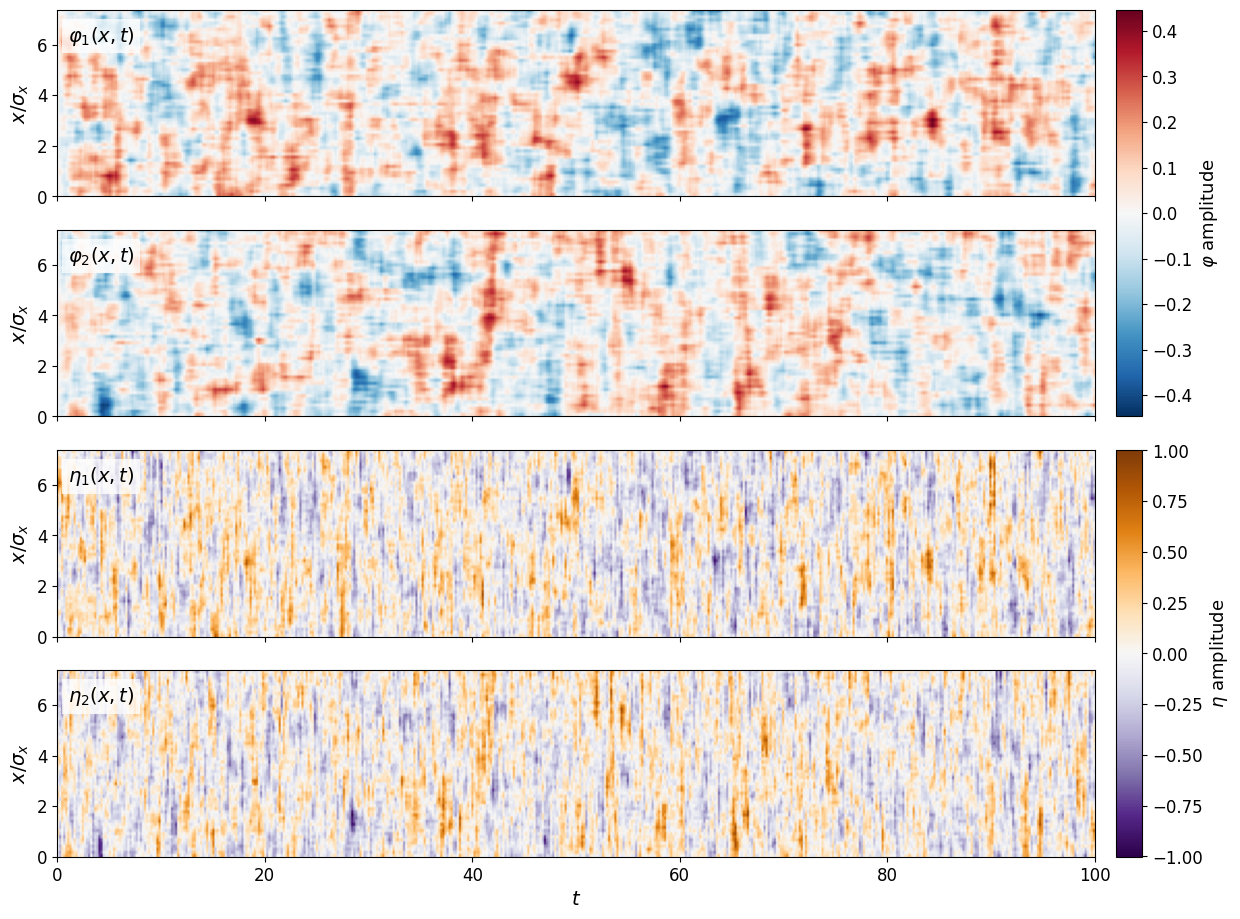

In [6]:
# ---------- Single-realisation heatmap of phi_1, phi_2 and the driving fields eta_1, eta_2 ----------

def single_realisation(n_sites=60, dt_sim=0.01, t_max=T_MAX, seed=0):
    rng = np.random.default_rng(seed)
    dx = sigma_x / 8.0
    x_grid = np.arange(n_sites) * dx
    n_steps = int(t_max / dt_sim)

    L_space = np.linalg.cholesky(
        np.exp(-np.abs(x_grid[:, None] - x_grid[None, :]) / sigma_x))
    rho = np.exp(-dt_sim / sigma_t)
    sig_innov = np.sqrt(lam * (1 - rho**2))
    sig_init = np.sqrt(lam)

    save_every = max(1, int(0.2 / dt_sim))  # snapshot every ~0.2 time units
    phi1_list, phi2_list = [], []
    eta1_list, eta2_list = [], []
    t_list = []

    z1_prev = sig_init * (L_space @ rng.standard_normal(n_sites))
    z2_prev = sig_init * (L_space @ rng.standard_normal(n_sites))
    eta1_k, eta2_k = z1_prev.copy(), z2_prev.copy()
    phi1, phi2 = np.zeros(n_sites), np.zeros(n_sites)

    phi1_list.append(phi1.copy())
    phi2_list.append(phi2.copy())
    eta1_list.append(eta1_k.copy())
    eta2_list.append(eta2_k.copy())
    t_list.append(0.0)

    for k in range(n_steps):
        z1_next = rho * z1_prev + sig_innov * (L_space @ rng.standard_normal(n_sites))
        z2_next = rho * z2_prev + sig_innov * (L_space @ rng.standard_normal(n_sites))
        eta1_kn, eta2_kn = z1_next, z2_next

        # Drift from F tensor
        phi_vec = np.stack([phi1, phi2])  # (2, n_sites)
        eta_vec = np.stack([eta1_k, eta2_k])
        eta_vec_n = np.stack([eta1_kn, eta2_kn])
        drift = -gamma * phi_vec + np.einsum('abc,b...,c...->a...', F, phi_vec, phi_vec) + eta_vec
        phi_p = phi_vec + dt_sim * drift
        drift_p = -gamma * phi_p + np.einsum('abc,b...,c...->a...', F, phi_p, phi_p) + eta_vec_n
        phi_vec = phi_vec + dt_sim / 2 * (drift + drift_p)
        phi1, phi2 = phi_vec[0], phi_vec[1]

        eta1_k, eta2_k = eta1_kn, eta2_kn
        z1_prev, z2_prev = z1_next, z2_next

        if (k + 1) % save_every == 0:
            phi1_list.append(phi1.copy())
            phi2_list.append(phi2.copy())
            eta1_list.append(eta1_k.copy())
            eta2_list.append(eta2_k.copy())
            t_list.append((k + 1) * dt_sim)

    return (x_grid, np.array(t_list),
            np.array(phi1_list), np.array(phi2_list),
            np.array(eta1_list), np.array(eta2_list))

x_wf, t_wf, phi1_wf, phi2_wf, eta1_wf, eta2_wf = single_realisation()
print(f'Trajectory: {phi1_wf.shape[0]} snapshots x {phi1_wf.shape[1]} sites')

# ---------- Waterfall heatmap (4 rows: phi_1, phi_2, eta_1, eta_2) ----------
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 11))
gs = GridSpec(
    4, 2, figure=fig,
    width_ratios=[40, 1],
    hspace=0.18, wspace=0.04,
)

ax_phi1 = fig.add_subplot(gs[0, 0])
ax_phi2 = fig.add_subplot(gs[1, 0], sharex=ax_phi1, sharey=ax_phi1)
ax_eta1 = fig.add_subplot(gs[2, 0], sharex=ax_phi1, sharey=ax_phi1)
ax_eta2 = fig.add_subplot(gs[3, 0], sharex=ax_phi1, sharey=ax_phi1)
cax_phi = fig.add_subplot(gs[0:2, 1])
cax_eta = fig.add_subplot(gs[2:4, 1])

extent = [t_wf[0], t_wf[-1], x_wf[0], x_wf[-1]]
vmax_phi = max(np.abs(phi1_wf).max(), np.abs(phi2_wf).max())
vmax_eta = max(np.abs(eta1_wf).max(), np.abs(eta2_wf).max())
kw_phi = dict(aspect='auto', origin='lower', cmap='RdBu_r',
              vmin=-vmax_phi, vmax=vmax_phi, extent=extent)
kw_eta = dict(aspect='auto', origin='lower', cmap='PuOr_r',
              vmin=-vmax_eta, vmax=vmax_eta, extent=extent)

ax_phi1.imshow(phi1_wf.T, **kw_phi)
im_phi = ax_phi2.imshow(phi2_wf.T, **kw_phi)
ax_eta1.imshow(eta1_wf.T, **kw_eta)
im_eta = ax_eta2.imshow(eta2_wf.T, **kw_eta)

for ax in (ax_phi1, ax_phi2, ax_eta1, ax_eta2):
    ax.set_ylabel(r'$x / \sigma_x$', fontsize=14)
for ax in (ax_phi1, ax_phi2, ax_eta1):
    ax.tick_params(labelbottom=False)
ax_eta2.set_xlabel('$t$', fontsize=14)

label_kw = dict(fontsize=14, va='top', fontweight='bold',
                bbox=dict(fc='white', alpha=0.75, ec='none'))
ax_phi1.text(0.01, 0.92, r'$\varphi_1(x, t)$', transform=ax_phi1.transAxes, **label_kw)
ax_phi2.text(0.01, 0.92, r'$\varphi_2(x, t)$', transform=ax_phi2.transAxes, **label_kw)
ax_eta1.text(0.01, 0.92, r'$\eta_1(x, t)$',    transform=ax_eta1.transAxes, **label_kw)
ax_eta2.text(0.01, 0.92, r'$\eta_2(x, t)$',    transform=ax_eta2.transAxes, **label_kw)

cb_phi = fig.colorbar(im_phi, cax=cax_phi)
cb_phi.set_label(r'$\varphi$ amplitude', fontsize=13)
cb_eta = fig.colorbar(im_eta, cax=cax_eta)
cb_eta.set_label(r'$\eta$ amplitude', fontsize=13)

fig.savefig('figures/waterfall.pdf', bbox_inches='tight', dpi=200)
plt.show()


In [7]:
# ---------- Evaluation grids ----------
r_fixed = 0.5
t_vals_fig2 = [1.0, 15.0, 30.0]             # Figure 2: xi vs r
r_grid_fig2 = np.linspace(0.0, 2.5, 11)
t_grid = np.logspace(np.log10(0.1), np.log10(T_MAX), 25)  # 25 points to T_MAX

# ---------- Shared plot style ----------
ORDER_COLORS = {0: '#4e79a7', 2: '#59a14f', 4: '#e15759'}
ORDER_LABELS = {
    0: r'$\xi^{(0)}$',
    2: r'$\xi^{(0{+}2)}$',
    4: r'$\xi^{(0{+}2{+}4)}$',
}
PAIR_COLORS  = {(0,0): '#1b9e77', (1,1): '#d95f02'}  # colourblind-safe
PAIR_MARKERS = {(0,0): 'o',       (1,1): 's'}
PAIR_LABELS  = {(0,0): r'$\xi_{11}$', (1,1): r'$\xi_{22}$'}

print(f'Time grid: {len(t_grid)} points, {t_grid[0]:.2f} to {t_grid[-1]:.1f}')


Time grid: 25 points, 0.10 to 100.0


In [8]:
# ---------- Compute perturbative corrections ----------
import time as _time
t0 = _time.perf_counter()

# xi(r_fixed, t) for each pair and order
print(f'Computing perturbative xi at r={r_fixed}...')
pert_by_t = {pair: {o: np.zeros(len(t_grid)) for o in ORDERS} for pair in PAIRS}
for ti, t_f in enumerate(t_grid):
    for a, b in PAIRS:
        res = xi_pert(a, b, r_fixed, t_f, max_order=4, ns=2**15)
        for o, v in res.items():
            pert_by_t[(a,b)][o][ti] = v
print(f'  Done ({_time.perf_counter()-t0:.1f}s)')

# Figure 2 data: xi vs r at fixed times
print('Computing xi vs r...')
pert_fig2 = {pair: {} for pair in PAIRS}
for t_f in t_vals_fig2:
    for a, b in PAIRS:
        order_data = {o: np.zeros(len(r_grid_fig2)) for o in ORDERS}
        for ri, r in enumerate(r_grid_fig2):
            res = xi_pert(a, b, r, t_f, max_order=4, ns=2**14)
            for o, v in res.items():
                order_data[o][ri] = v
        pert_fig2[(a, b)][t_f] = order_data
    print(f'  t={t_f:.1f} done')

# Cumulative sums
xi_pert_cumul = {}
for a, b in PAIRS:
    xi_pert_cumul[(a,b)] = sum(pert_by_t[(a,b)][o] for o in ORDERS)

# Simulation at r_fixed — interpolate onto t_grid
ri_sim = np.argmin(np.abs(sim_r - r_fixed))
xi_sim = {}
for a, b in PAIRS:
    xi_sim[(a,b)] = np.interp(t_grid, sim_t, sim_data[(a,b)]['xi'][:, ri_sim])

# --- Error estimates ---
# 1. MC noise: sigma/sqrt(N)
mc_noise = {}
for a, b in PAIRS:
    xi0 = np.interp(t_grid, sim_t, sim_data[(a,b)]['xi'][:, 0])
    mc_noise[(a,b)] = np.sqrt(xi0**2 + xi_sim[(a,b)]**2) / np.sqrt(sim_n_real)

# 2. Heun bias estimate: C * dt^2.  Estimate C from the perturbative value.
#    For Heun, the leading bias in <phi^2> scales as ~ xi * gamma * dt^2.
#    This is a rough estimate.
dt_sim = 0.02  # must match run_simulation.py
heun_bias = {}
for a, b in PAIRS:
    heun_bias[(a,b)] = xi_pert_cumul[(a,b)] * gamma * dt_sim**2

# 3. Combined error envelope: sqrt(mc^2 + heun_bias^2)
total_noise = {}
for a, b in PAIRS:
    total_noise[(a,b)] = np.sqrt(mc_noise[(a,b)]**2 + heun_bias[(a,b)]**2)

print(f'Total: {_time.perf_counter()-t0:.1f}s')


Computing perturbative xi at r=0.5...


  Done (53.1s)
Computing xi vs r...


  t=1.0 done


  t=15.0 done


  t=30.0 done
Total: 122.1s


## Figure 1: $\xi_{ab}(r{=}0.5, t)$ — perturbative expansion vs simulation

**Left column**: $\xi_{11}$ and $\xi_{22}$ on the same axes, with cumulative perturbative
orders as lines and simulation as points with error bars.
**Right column**: absolute residual $\Delta\xi = \xi_{\rm pert} - \xi_{\rm sim}$
with the combined error envelope (MC noise $\oplus$ Heun bias) shaded.

/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_28808/649218654.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.93])


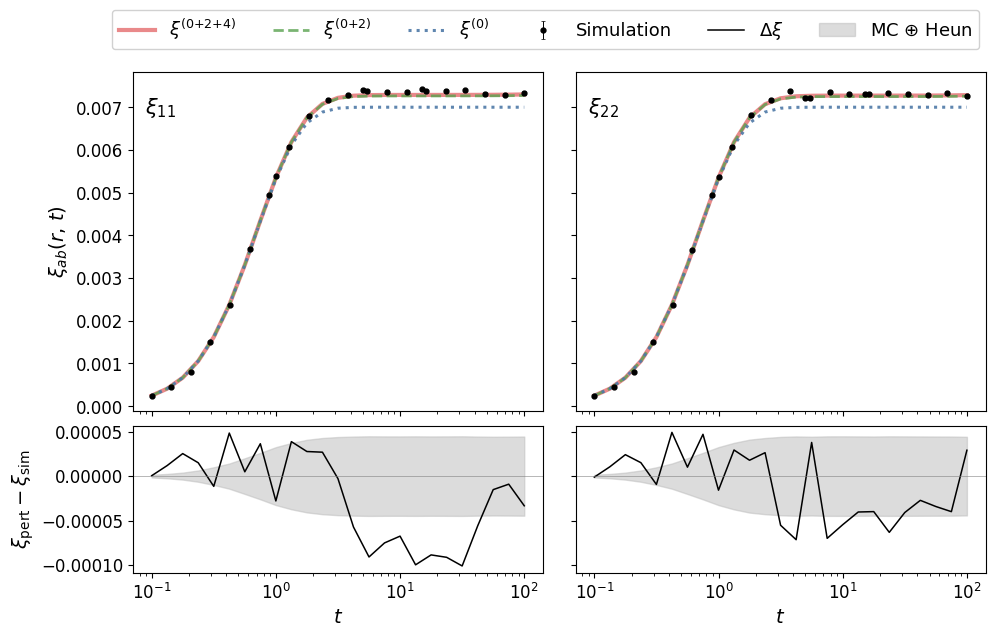

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5),
                          gridspec_kw={'height_ratios': [3, 1.3],
                                       'hspace': 0.06, 'wspace': 0.08},
                          sharex=True, sharey='row')

for col, (a, b) in enumerate(PAIRS):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    # --- Top: cumulative perturbative orders + simulation ---
    # Plot widest/most opaque first, then overlay narrower/more transparent
    cumul = np.zeros(len(t_grid))
    order_data = []  # collect (cumul, order) then plot in reverse width order
    for order in ORDERS:
        cumul = cumul + pert_by_t[(a,b)][order]
        order_data.append((cumul.copy(), order))

    # Plot: solid (widest) first, then dashed, then dotted (thinnest on top)
    for cumul_arr, order in reversed(order_data):
        if order == max(ORDERS):
            lw, ls, alpha = 3.0, '-', 0.7
        elif order == 2:
            lw, ls, alpha = 2.0, '--', 0.8
        else:
            lw, ls, alpha = 2.2, ':', 0.9
        ax_top.plot(t_grid, cumul_arr, color=ORDER_COLORS[order],
                    lw=lw, ls=ls, alpha=alpha,
                    label=ORDER_LABELS[order] if col == 0 else None)

    # Simulation on top
    t_mask = (sim_t >= t_grid[0]) & (sim_t <= t_grid[-1])
    t_pts = sim_t[t_mask]
    v_pts = sim_data[(a,b)]['xi'][t_mask, ri_sim]
    e_pts = np.sqrt(
        sim_data[(a,b)]['xi'][t_mask, 0]**2 + v_pts**2
    ) / np.sqrt(sim_n_real)
    ax_top.errorbar(t_pts, v_pts, yerr=e_pts,
                    fmt='o', color='k', ms=3.5, lw=0.7,
                    capsize=1.5, capthick=0.5, zorder=5,
                    label='Simulation' if col == 0 else None)

    ax_top.set_xscale('log')
    ax_top.tick_params(labelbottom=False)
    ax_top.text(0.03, 0.93, PAIR_LABELS[(a,b)],
               transform=ax_top.transAxes, fontsize=15,
               va='top', fontweight='bold')
    if col == 0:
        ax_top.set_ylabel(r'$\xi_{ab}(r,\,t)$')

    # --- Bottom: residual ---
    residual = xi_pert_cumul[(a,b)] - xi_sim[(a,b)]
    ax_bot.plot(t_grid, residual, 'k-', lw=1.1,
               label=r'$\Delta\xi$' if col == 0 else None)
    env = total_noise[(a,b)]
    ax_bot.fill_between(t_grid, -env, env,
                        color='#bbbbbb', alpha=0.5,
                        label=r'MC $\oplus$ Heun' if col == 0 else None)
    ax_bot.axhline(0, color='gray', lw=0.4)
    ax_bot.set_xscale('log')
    ax_bot.set_xlabel('$t$')
    if col == 0:
        ax_bot.set_ylabel(r'$\xi_{\rm pert} - \xi_{\rm sim}$')

handles, labels = axes[0, 0].get_legend_handles_labels()
h2, l2 = axes[1, 0].get_legend_handles_labels()
handles += h2; labels += l2
fig.legend(handles, labels, loc='upper center',
           ncol=len(handles), fontsize=13, framealpha=0.9,
           bbox_to_anchor=(0.5, 0.99))
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig('figures/xi_vs_time.pdf', bbox_inches='tight', dpi=200)
plt.show()


## Error budget

| Source | Formula | Typical magnitude |
|--------|---------|-------------------|
| MC simulation noise | $\sigma / \sqrt{N}$ | $\sim 0.4\%$ at $N = 50\,000$ |
| Heun discretisation bias | $\sim \xi \gamma \Delta t^2$ | $\sim 0.04\%$ at $\Delta t = 0.02$ |
| Numerical integration (pert.) | QMC seed variance | $\sim 20\%$ of $\xi^{(4)}$ at $2^{15}$ samples |
| Perturbative truncation | $\xi^{(6)} + \cdots > 0$ | always positive; makes $\xi_{\rm pert}$ a lower bound |

**Key finding**: with the default Gauss-Legendre integrator (`method='gl'`), the numerical
integration error is reduced to $< 0.1\%$ of $\xi^{(4)}$ — negligible compared to MC noise.
The previous QMC integrator (`method='qmc'`) had $\sim 20\%$ seed-dependent noise on the
order-4 contribution, which dominated the residual and created an apparent systematic bias.

Since all perturbative corrections are positive (proven from the MSR sign structure),
$\xi_{\rm pert}$ at order 4 is a **lower bound** on the exact value.
Any remaining $\xi_{\rm pert} < \xi_{\rm sim}$ discrepancy is MC simulation noise;
any $\xi_{\rm pert} > \xi_{\rm sim}$ at late times would indicate simulation underestimation
(Heun bias) rather than perturbative error.

In [10]:
# ---------- Error budget table ----------
print(f'Error budget at r={r_fixed},  N={sim_n_real:,},  dt={dt_sim}')
print(f'{"":>6s}  {"───── ξ_11 ─────":>36s}  {"───── ξ_22 ─────":>36s}')
print(f'{"t":>6s}  {"pert":>9s} {"sim":>9s} {"Δ":>9s} {"σ_tot":>7s}  '
      f'{"pert":>9s} {"sim":>9s} {"Δ":>9s} {"σ_tot":>7s}')
print('-' * 82)
for tv in [0.5, 1.0, 3.0, 5.0, 10.0, 20.0, 30.0, 50.0]:
    ti = np.argmin(np.abs(t_grid - tv))
    if abs(t_grid[ti] - tv) > 0.5 * tv:
        continue
    row = f'{t_grid[ti]:6.1f}'
    for a, b in PAIRS:
        xp = xi_pert_cumul[(a,b)][ti]
        xs = xi_sim[(a,b)][ti]
        dx = xp - xs
        sig = total_noise[(a,b)][ti]
        row += f'  {xp:9.4e} {xs:9.4e} {dx:+9.1e} {sig:7.1e}'
    print(row)

print(f'\n--- Truncation crossover ---')
for a, b in PAIRS:
    res = np.abs(xi_pert_cumul[(a,b)] - xi_sim[(a,b)])
    sig = total_noise[(a,b)]
    exceed = t_grid[res > 2 * sig]
    t_cross = exceed[0] if len(exceed) else t_grid[-1]
    nz = sum(len(integrands.get((o,a,b), [])) for o in [2,4])
    print(f'  {PAIR_LABELS[(a,b)]}: |Δξ| > 2σ at t > {t_cross:.1f}  '
          f'({nz} diagrams at orders 2+4)')


Error budget at r=0.5,  N=100,000,  dt=0.02
                            ───── ξ_11 ─────                      ───── ξ_22 ─────
     t       pert       sim         Δ   σ_tot       pert       sim         Δ   σ_tot
----------------------------------------------------------------------------------
   0.6  3.3059e-03 3.3010e-03  +4.9e-06 2.0e-05  3.3059e-03 3.2958e-03  +1.0e-05 2.0e-05
   1.0  5.3492e-03 5.3772e-03  -2.8e-05 3.3e-05  5.3491e-03 5.3649e-03  -1.6e-05 3.3e-05
   3.2  7.2183e-03 7.2211e-03  -2.8e-06 4.4e-05  7.2080e-03 7.2633e-03  -5.5e-05 4.4e-05
   5.6  7.2822e-03 7.3733e-03  -9.1e-05 4.5e-05  7.2670e-03 7.2291e-03  +3.8e-05 4.4e-05
  10.0  7.2859e-03 7.3535e-03  -6.8e-05 4.5e-05  7.2701e-03 7.3248e-03  -5.5e-05 4.5e-05
  17.8  7.2862e-03 7.3749e-03  -8.9e-05 4.5e-05  7.2702e-03 7.3102e-03  -4.0e-05 4.5e-05
  31.6  7.2869e-03 7.3881e-03  -1.0e-04 4.5e-05  7.2706e-03 7.3116e-03  -4.1e-05 4.5e-05
  56.2  7.2893e-03 7.3045e-03  -1.5e-05 4.4e-05  7.2725e-03 7.3068e-03  -3.4e-05 4

## Figure 2: $\xi_{ab}(r)$ at fixed times

Perturbative prediction vs simulation as a function of spatial separation,
at three representative times. Shared y-axis across panels.

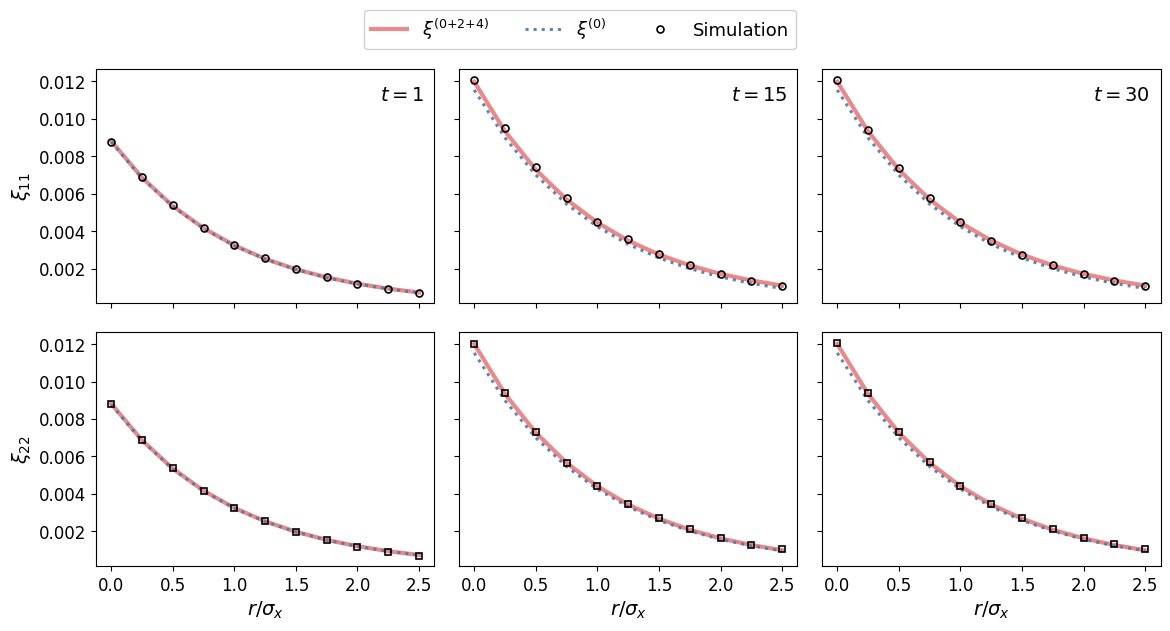

In [11]:
fig, axes = plt.subplots(len(PAIRS), len(t_vals_fig2),
                          figsize=(4.0*len(t_vals_fig2), 3.2*len(PAIRS)),
                          sharex=True, sharey='row')

for col, t_f in enumerate(t_vals_fig2):
    ti = np.argmin(np.abs(sim_t - t_f))

    for row, (a, b) in enumerate(PAIRS):
        ax = axes[row, col]
        od = pert_fig2[(a, b)][t_f]

        # Full cumulative (widest, background)
        cumul = od[0] + od[2] + od[4]
        ax.plot(r_grid_fig2, cumul, color=ORDER_COLORS[4],
                lw=3.0, alpha=0.7,
                label=ORDER_LABELS[4] if col == 0 and row == 0 else None)

        # Zeroth order (narrow, on top)
        ax.plot(r_grid_fig2, od[0], color=ORDER_COLORS[0],
                lw=2.2, ls=':', alpha=0.9,
                label=ORDER_LABELS[0] if col == 0 and row == 0 else None)

        # Simulation markers on top
        sim_vals = np.interp(r_grid_fig2, sim_r,
                             sim_data[(a, b)]['xi'][ti, :])
        mk = PAIR_MARKERS[(a, b)]
        ax.plot(r_grid_fig2, sim_vals, mk, color='k', ms=5,
                mfc='none', mew=1.2, zorder=5,
                label='Simulation' if col == 0 and row == 0 else None)

        if col == 0:
            ax.set_ylabel(PAIR_LABELS[(a,b)])
        if row == 0:
            ax.text(0.97, 0.93, f'$t = {t_f:.0f}$',
                    transform=ax.transAxes, fontsize=14,
                    va='top', ha='right', fontweight='bold')
        if row == len(PAIRS) - 1:
            ax.set_xlabel(r'$r / \sigma_x$')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center',
           ncol=len(handles), fontsize=13, framealpha=0.9,
           bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig('figures/comparison_multi_time.pdf', bbox_inches='tight', dpi=200)
plt.show()


## Figure 3: Perturbative convergence at a fixed point

How the cumulative perturbative sum converges toward the simulation value.

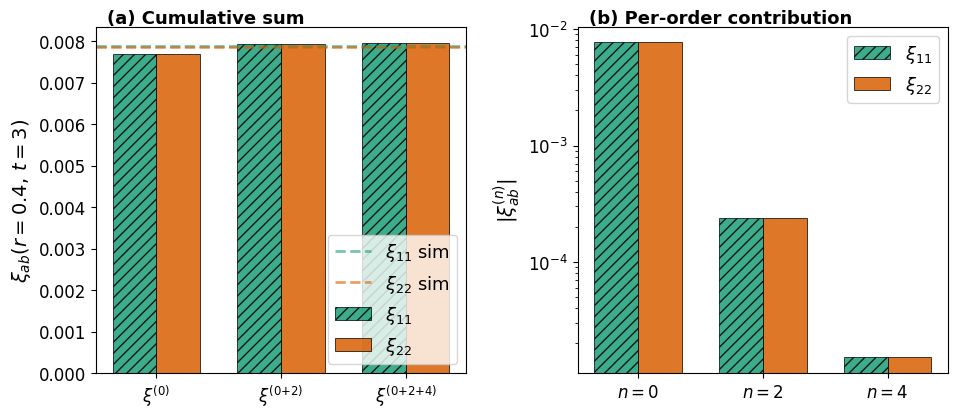

In [12]:
r_pt, t_pt = 0.4, 3.0

order_vals = {}
for a, b in PAIRS:
    order_vals[(a, b)] = xi_pert(a, b, r_pt, t_pt, max_order=4, ns=2**15)
sim_pt = {pair: sim_at(*pair, r_pt, t_pt) for pair in PAIRS}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5),
                          gridspec_kw={'wspace': 0.3})

x = np.arange(len(ORDERS))
bw = 0.35
PAIR_HATCHES = {(0,0): '///', (1,1): ''}

# (a) Cumulative sum
ax = axes[0]
for ip, (a, b) in enumerate(PAIRS):
    vals = order_vals[(a, b)]
    cumul = np.cumsum([vals[o] for o in ORDERS])
    ax.bar(x + ip*bw, cumul, bw,
           color=PAIR_COLORS[(a,b)], edgecolor='k', lw=0.6,
           hatch=PAIR_HATCHES[(a,b)], alpha=0.85,
           label=PAIR_LABELS[(a,b)])
    ax.axhline(sim_pt[(a,b)], color=PAIR_COLORS[(a,b)],
               ls='--', lw=2, alpha=0.6,
               label=PAIR_LABELS[(a,b)] + ' sim' if ip == 0 else
                     (PAIR_LABELS[(a,b)] + ' sim'))

ax.set_xticks(x + bw/2)
ax.set_xticklabels([ORDER_LABELS[o] for o in ORDERS])
ax.set_ylabel(rf'$\xi_{{ab}}(r{{=}}{r_pt},\, t{{=}}{t_pt:.0f})$')
# Deduplicate legend: show each pair once (bar) + 'sim' once
h, l = ax.get_legend_handles_labels()
by_label = dict(zip(l, h))
ax.legend(by_label.values(), by_label.keys(), loc='lower right', fontsize=13)
ax.text(0.03, 1.05, '(a) Cumulative sum',
        transform=ax.transAxes, va='top', fontweight='bold')

# (b) Per-order contributions
ax = axes[1]
for ip, (a, b) in enumerate(PAIRS):
    vals = order_vals[(a, b)]
    contribs = [abs(vals[o]) for o in ORDERS]
    ax.bar(x + ip*bw, contribs, bw,
           color=PAIR_COLORS[(a,b)], edgecolor='k', lw=0.6,
           hatch=PAIR_HATCHES[(a,b)], alpha=0.85,
           label=PAIR_LABELS[(a,b)])

ax.set_yscale('log')
ax.set_xticks(x + bw/2)
ax.set_xticklabels([f'$n={o}$' for o in ORDERS])
ax.set_ylabel(r'$|\xi^{(n)}_{ab}|$')
ax.legend(loc='upper right', fontsize=13)
ax.text(0.03, 1.05, '(b) Per-order contribution',
        transform=ax.transAxes, va='top', fontweight='bold')

fig.savefig('figures/xi_vs_order.pdf', bbox_inches='tight', dpi=200)
plt.show()
